**1.Data Processing and Necessary imports**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

#configure machine
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs = 15

# data processing
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5))])
train_loader = DataLoader(datasets.MNIST(".",train=True,download=True,transform=transform),batch_size=64,shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.39MB/s]


**2.Creating VAE(Variational Autoencoder)**

In [2]:
class VAE(nn.Module):
  def __init__(self):
    super(VAE,self).__init__()
    self.encoder = nn.Sequential(nn.Linear(784,400), nn.ReLU())
    self.fc_mean = nn.Linear(400,32)
    self.fc_log_variance = nn.Linear(400,32)
    self.decoder = nn.Sequential(nn.Linear(32,400),nn.ReLU(),nn.Linear(400,784),nn.Tanh())

  def reparametrize(self,mean,log_variance):
    std = torch.exp(0.5 * log_variance)
    eps = torch.randn_like(std)
    return mean + eps * std

  def forward(self,x):
    h = self.encoder(x.view(-1,784))
    mean , log_variance = self.fc_mean(h) , self.fc_log_variance(h)
    z = self.reparametrize(mean,log_variance)
    return self.decoder(z),mean,log_variance


**3.Creating GAN Model**

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(32, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
      return self.model(x.view(-1, 784))

**4.Training of VAE and GAN**

In [6]:
# training
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

# Initialization
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
gen_optimizer = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(1, 11):
    vae.train()
    gen.train()
    disc.train()

    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        vae_optimizer.zero_grad()
        recon_batch, mean, log_variance = vae(imgs)
        recon_loss = nn.functional.mse_loss(recon_batch, imgs.view(-1, 784), reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + log_variance - mean.pow(2) - log_variance.exp())
        vae_loss = (recon_loss + kld_loss) / imgs.size(0)
        vae_loss.backward()
        vae_optimizer.step()

        # Train Discriminator
        disc_optimizer.zero_grad()
        z = torch.randn(imgs.size(0), 32).to(device)
        fake_imgs = gen(z)
        real_loss = criterion(disc(imgs), real_labels)
        fake_loss = criterion(disc(fake_imgs.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        disc_optimizer.step()

        # Train Generator
        gen_optimizer.zero_grad()
        g_loss = criterion(disc(fake_imgs), real_labels)
        g_loss.backward()
        gen_optimizer.step()

    print(f"Epoch [{epoch}/10] | VAE Loss: {vae_loss.item():.2f} | G Loss: {g_loss.item():.2f} | D Loss: {d_loss.item():.2f}")


Epoch [1/10] | VAE Loss: 91.55 | G Loss: 1.59 | D Loss: 0.45
Epoch [2/10] | VAE Loss: 76.96 | G Loss: 1.71 | D Loss: 0.41
Epoch [3/10] | VAE Loss: 71.09 | G Loss: 3.10 | D Loss: 0.58
Epoch [4/10] | VAE Loss: 71.66 | G Loss: 2.16 | D Loss: 0.41
Epoch [5/10] | VAE Loss: 70.69 | G Loss: 1.41 | D Loss: 0.43
Epoch [6/10] | VAE Loss: 71.00 | G Loss: 0.73 | D Loss: 0.56
Epoch [7/10] | VAE Loss: 63.86 | G Loss: 1.72 | D Loss: 0.58
Epoch [8/10] | VAE Loss: 64.04 | G Loss: 1.00 | D Loss: 0.65
Epoch [9/10] | VAE Loss: 65.84 | G Loss: 1.03 | D Loss: 0.60
Epoch [10/10] | VAE Loss: 71.85 | G Loss: 1.23 | D Loss: 0.54


**5.Visualize Image**

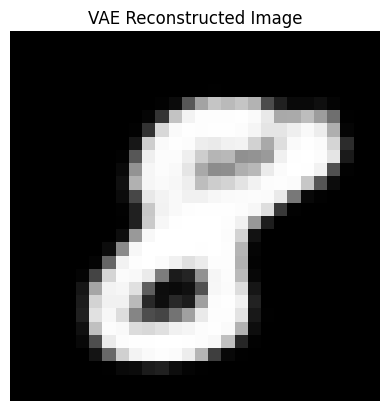

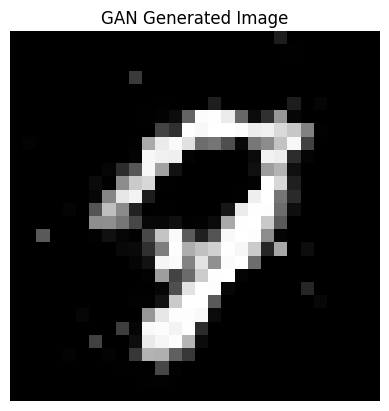

In [5]:
import matplotlib.pyplot as plt

vae.eval()

with torch.no_grad():

    imgs, _ = next(iter(train_loader))

    imgs = imgs.to(device)

    recon_imgs, _, _ = vae(imgs)

    recon_img = recon_imgs[0].cpu()

# Plot image
plt.imshow(recon_img.view(28, 28), cmap='gray')
plt.title("VAE Reconstructed Image")
plt.axis('off')
plt.show()

gen.eval()

with torch.no_grad():

    z = torch.randn(1, 32).to(device)

    fake_img = gen(z).cpu()

plt.imshow(fake_img[0].view(28, 28), cmap='gray')
plt.title("GAN Generated Image")
plt.axis('off')
plt.show()